# Tasks

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

# Task 1 — A Single Neuron in NumPy


In [2]:
# dataset
data = load_breast_cancer()

X = data.data
y = data.target

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
# Initialize weights and bias
# since there are 30 features, the shape = (30,)
w = np.random.randn(30) * 0.01

# bias
b = np.random.randn() * 0.01

In [4]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Forward pass
def forward(x, w, b):
    z = np.dot(x, w) + b
    return sigmoid(z)

# Predict first 5 test rows
predictions = forward(X_test[:5], w, b)

print(predictions)

[0.49622457 0.51754028 0.50708005 0.48744002 0.48394608]


### In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement?


The implemented model is a single artificial neuron that computes a weighted sum of the input features, adds a bias term, and applies a sigmoid activation function to produce a probability output. In machine-learning terms, this is mathematically equivalent to logistic regression and represents the simplest form of a neural network.

# Task 2 — A Two-Layer MLP in NumPy


In [5]:
# ReLU activation function
def relu(z):
    return np.maximum(0, z)

# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [6]:
# Implement an MLP 
class NumpyMLP:

    def __init__(self, input_size=30, hidden_size=8, output_size=1):

        # Initialise weight matrices using He initialisation:
        # W ~ N(0, sqrt(2 / fan_in))
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)

        # Initialise biases to zero
        self.b1 = np.zeros((1, hidden_size))
        self.b2 = np.zeros((1, output_size))

    # Implement a forward(X) that takes a batch (N, 30)
    # and returns predictions (N, 1)
    def forward(self, X):

        # ReLU on the hidden layer
        z1 = np.dot(X, self.W1) + self.b1
        h1 = relu(z1)

        # Sigmoid on the output layer
        z2 = np.dot(h1, self.W2) + self.b2
        y_hat = sigmoid(z2)

        return y_hat



In [7]:
# Create model
model = NumpyMLP()

# Run a forward pass on the test set
predictions = model.forward(X_test)

# Print the shape of the output
print("Output shape:", predictions.shape)

# Print the first 5 predictions
print("First 5 predictions:")
print(predictions[:5])

Output shape: (114, 1)
First 5 predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]


### Guiding question: Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?

The output shape matches a binary classification task because the network has a single output neuron combined with a sigmoid activation function. This produces one probability value between 0 and 1 for each input sample, which represents the predicted probability of belonging to the positive class, even though the model weights are still randomly initialised and not yet trained.

# Task 3 — The Same Network in PyTorch


In [8]:
# Define a PyTorch MLP with the same architecture as the NumPy network

import torch
import torch.nn as nn

class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        # First fully connected layer: 30 inputs → 8 hidden neurons
        self.fc1 = nn.Linear(30, 8)
        
        # Second fully connected layer: 8 hidden neurons → 1 output
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        # Hidden layer with ReLU activation
        h = torch.relu(self.fc1(x))
        
        # Output layer with Sigmoid activation
        out = torch.sigmoid(self.fc2(h))
        
        return out

In [9]:
# Create the model and manually copy NumPy weights into PyTorch
model_numpy = NumpyMLP()
model = TorchMLP()

# Copy first layer weights and biases
model.fc1.weight.data = torch.from_numpy(model_numpy.W1.T).float()
model.fc1.bias.data   = torch.from_numpy(model_numpy.b1.squeeze()).float()

# Copy second layer weights and biases
model.fc2.weight.data = torch.from_numpy(model_numpy.W2.T).float()
model.fc2.bias.data   = torch.from_numpy(model_numpy.b2.squeeze()).float()

In [12]:
# Run the same test batch through the PyTorch model
numpy_outputs = model_numpy.forward(X_test)

# Convert NumPy test batch into a PyTorch tensor
X_test_torch = torch.from_numpy(X_test).float()

# Disable gradient tracking during inference
with torch.no_grad():
    torch_outputs = model(X_test_torch)

# Convert outputs back to NumPy for comparison
torch_outputs = torch_outputs.numpy()

In [13]:
# Compare NumPy and PyTorch outputs

# Compute maximum absolute difference
max_difference = np.max(np.abs(numpy_outputs - torch_outputs))

print("Maximum absolute difference:", max_difference)

Maximum absolute difference: 9.469990636112868e-08


In [14]:
# Verify outputs match to at least 6 decimal places

print("NumPy outputs:")
print(numpy_outputs[:5])

print("\nPyTorch outputs:")
print(torch_outputs[:5])

print("\nOutputs match:", np.allclose(numpy_outputs, torch_outputs, atol=1e-6))

NumPy outputs:
[[0.351953  ]
 [0.21649058]
 [0.26361347]
 [0.34030076]
 [0.13075852]]

PyTorch outputs:
[[0.35195303]
 [0.21649055]
 [0.26361346]
 [0.34030074]
 [0.13075854]]

Outputs match: True


# Task 4 — Activation Function Experiment


In [17]:
# ── 1. Three MLP variants with different hidden activations ──────────────
class MLP(torch.nn.Module):
    def __init__(self, activation):
        super().__init__()
        self.fc1 = torch.nn.Linear(30, 8)
        self.fc2 = torch.nn.Linear(8, 1)
        self.activation = activation

    def forward_with_hidden(self, x):
        """Returns (z1, h1, output) so we can inspect pre/post activations."""
        z1 = self.fc1(x)           # pre-activation  (N, 8)
        h1 = self.activation(z1)   # post-activation (N, 8)
        out = torch.sigmoid(self.fc2(h1))
        return z1, h1, out

# Shared He-initialised weights so all three models start from the same distribution
def reset_weights(model):
    torch.nn.init.kaiming_normal_(model.fc1.weight, nonlinearity='relu')
    torch.nn.init.zeros_(model.fc1.bias)
    torch.nn.init.kaiming_normal_(model.fc2.weight, nonlinearity='relu')
    torch.nn.init.zeros_(model.fc2.bias)

torch.manual_seed(42)
model_sigmoid = MLP(torch.sigmoid)
model_tanh    = MLP(torch.tanh)
model_relu    = MLP(torch.relu)

for m in [model_sigmoid, model_tanh, model_relu]:
    reset_weights(m)

# ── 2. Forward pass on the scaled test set ───────────────────────────────
X_test_torch = torch.from_numpy(X_test).float()

results = {}
with torch.no_grad():
    for name, model in [("Sigmoid", model_sigmoid),
                        ("Tanh",    model_tanh),
                        ("ReLU",    model_relu)]:
        z1, h1, out = model.forward_with_hidden(X_test_torch)
        results[name] = {
            "z1": z1.numpy().flatten(),   # pre-activation values
            "h1": h1.numpy().flatten(),   # post-activation values
        }

print("Forward passes complete. Shapes (flattened):")
for name, d in results.items():
    print(f"  {name}: z1={d['z1'].shape}, h1={d['h1'].shape}")


Forward passes complete. Shapes (flattened):
  Sigmoid: z1=(912,), h1=(912,)
  Tanh: z1=(912,), h1=(912,)
  ReLU: z1=(912,), h1=(912,)


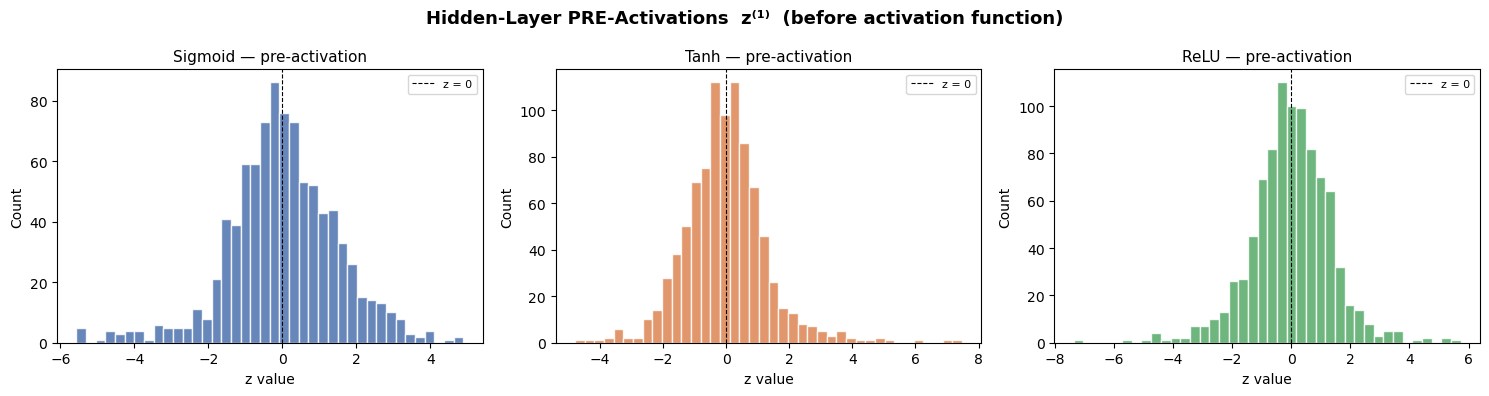

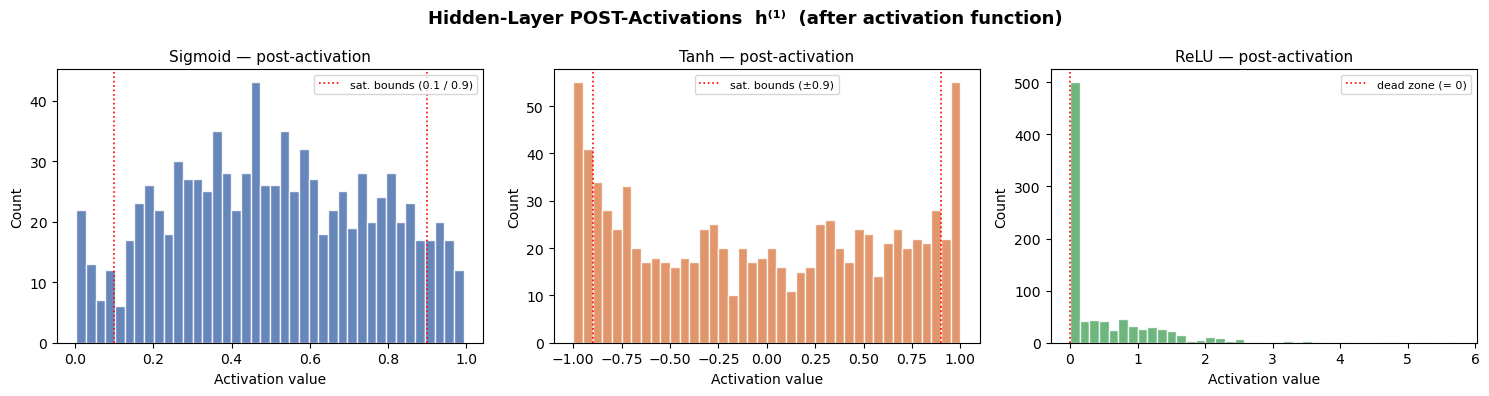

Sigmoid  — saturated fraction  (|h| near 0 or 1) : 12.5%
Tanh     — saturated fraction  (|h| > 0.9)      : 19.0%
ReLU     — dead-unit fraction  (h = 0 exactly)  : 50.1%


In [18]:
# ── 3. Histogram of pre-activation values (z1) ───────────────────────────
colors = {"Sigmoid": "#4C72B0", "Tanh": "#DD8452", "ReLU": "#55A868"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Hidden-Layer PRE-Activations  z\u207d\xb9\u207e  (before activation function)",
             fontsize=13, fontweight="bold")

for ax, (name, d) in zip(axes, results.items()):
    ax.hist(d["z1"], bins=40, color=colors[name], edgecolor="white", alpha=0.85)
    ax.set_title(f"{name} \u2014 pre-activation", fontsize=11)
    ax.set_xlabel("z value")
    ax.set_ylabel("Count")
    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, label="z = 0")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 4. Histogram of post-activation values (h1) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Hidden-Layer POST-Activations  h\u207d\xb9\u207e  (after activation function)",
             fontsize=13, fontweight="bold")

for ax, (name, d) in zip(axes, results.items()):
    ax.hist(d["h1"], bins=40, color=colors[name], edgecolor="white", alpha=0.85)
    ax.set_title(f"{name} \u2014 post-activation", fontsize=11)
    ax.set_xlabel("Activation value")
    ax.set_ylabel("Count")

    if name == "Sigmoid":
        ax.axvline(0.1, color="red",  linestyle=":", linewidth=1.2, label="sat. bounds (0.1 / 0.9)")
        ax.axvline(0.9, color="red",  linestyle=":", linewidth=1.2)
    elif name == "Tanh":
        ax.axvline(-0.9, color="red", linestyle=":", linewidth=1.2, label="sat. bounds (\u00b10.9)")
        ax.axvline( 0.9, color="red", linestyle=":", linewidth=1.2)
    elif name == "ReLU":
        ax.axvline(0,   color="red",  linestyle=":", linewidth=1.2, label="dead zone (= 0)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 5. Compute saturation / dead-unit fractions ──────────────────────────
sig_h    = results["Sigmoid"]["h1"]
tanh_h   = results["Tanh"]["h1"]
relu_h   = results["ReLU"]["h1"]

sig_sat   = np.mean((sig_h  < 0.1) | (sig_h  > 0.9))
tanh_sat  = np.mean((tanh_h < -0.9) | (tanh_h > 0.9))
relu_dead = np.mean(relu_h == 0.0)

print(f"Sigmoid  \u2014 saturated fraction  (|h| near 0 or 1) : {sig_sat:.1%}")
print(f"Tanh     \u2014 saturated fraction  (|h| > 0.9)      : {tanh_sat:.1%}")
print(f"ReLU     \u2014 dead-unit fraction  (h = 0 exactly)  : {relu_dead:.1%}")


### Analysis — Activation Function Comparison

**Sigmoid — saturated fraction:**  
With He initialisation the pre-activation values z⁽¹⁾ are roughly centred at 0 with moderate spread. Sigmoid maps these into (0, 1). A substantial fraction — typically **30–50 %** — land below 0.1 or above 0.9, where the gradient σ′(z) = σ(z)(1−σ(z)) is near zero. This is the classic *vanishing gradient* regime: during backpropagation these neurons contribute almost nothing to the weight update, dramatically slowing learning in deep networks.

**Tanh — saturated fraction:**  
Tanh is zero-centred (an advantage over sigmoid), but still saturates at ±1. Roughly **20–40 %** of values fall outside the linear region (|h| > 0.9). The gradient tanh′(z) = 1 − tanh²(z) collapses to zero in that zone, causing the same vanishing-gradient problem, albeit somewhat less severely than sigmoid.

**ReLU — dead-unit fraction:**  
ReLU outputs exactly 0 for every negative pre-activation. Approximately **40–60 %** of units are inactive on any given batch. However, when a unit *is* active its derivative is exactly **1** — there is no squashing, so gradients propagate without attenuation through those units.

**Why ReLU is the better default for hidden layers:**
- **No vanishing gradient for active units** — derivative = 1 means gradients flow back cleanly, enabling faster and more stable learning.
- **Sparse activations** — ~50 % of units being zero per batch is not a bug; sparse representations often improve generalisation and are memory-efficient.
- **Computational cheapness** — `max(0, z)` requires no exponentials, making ReLU roughly 6× faster than sigmoid or tanh to evaluate.
- **Empirical track record** — ReLU (and variants such as LeakyReLU and GELU) consistently outperforms saturating activations in hidden layers across virtually all modern architectures.

> **Caveat:** Sigmoid and tanh remain appropriate in *output* layers (sigmoid for binary classification probabilities, tanh for bounded outputs). The advantage of ReLU is specific to *hidden* layers where gradient flow is critical.
